In [73]:
import numpy as np
import pandas as pd
import scipy
import scipy.stats
import matplotlib as mpl   
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import t, norm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [74]:
def get_stock_data(ticker, max, start_date, end_date):
    try:
        # https://medium.com/nerd-for-tech/all-you-need-to-know-about-yfinance-yahoo-finance-library-fa4c6e48f08e
        data = yf.Ticker(ticker)
        if max == False:
            data = data.history(start=start_date, end=end_date)
        else:
            data = data.history(period="max")
        return data
    except Exception as e:
        return f"Error fetching data: {e}"

In [75]:
#demo index
stock_data = get_stock_data("PREIX", False,"2000-01-01", "2024-10-01")
stock_data.asfreq('B').index  # set index frequency to business daliy
stock_data['Daily Return'] = stock_data['Close'].pct_change()  # percentage return
stock_data['Log Return'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))

In [76]:
#simple threshold determination (based on SD, mean, etc. -- to be experimented with)

mean_return = stock_data['Daily Return'].mean()
std_return = stock_data['Daily Return'].std()

# Define thresholds
up_threshold = mean_return + std_return
down_threshold = mean_return - std_return

def classify_state(return_value, up_thresh, down_thresh):
    if return_value > up_thresh:
        return 'Up'
    elif return_value < down_thresh:
        return 'Down'
    else:
        return 'Stagnant'

stock_data['Markov State'] = stock_data['Daily Return'].apply(lambda x: classify_state(x, up_threshold, down_threshold))

In [77]:
#transition matrix creation (probabilities of achieving various states based on prev states)

# Shift 'Markov State' column to get previous state
stock_data['Prev State'] = stock_data['Markov State'].shift(1)

# Create a transition matrix and Normalize to get probabilities
transition_counts = pd.crosstab(stock_data['Prev State'], stock_data['Markov State'])
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

In [78]:
#establish stationary equilibrium matrix

def find_equilibrium(P):
    """
    Compute stationary distribution of a Markov transition matrix P.
    Assumes P is row-stochastic (rows sum to 1).
    """

    # Ensure rows sum to 1 (defensive normalization)
    P = P / P.sum(axis=1, keepdims=True)

    # Compute eigenvalues/eigenvectors of P^T
    eigvals, eigvecs = np.linalg.eig(P.T)

    # Find eigenvector corresponding to eigenvalue 1
    idx = np.argmin(np.abs(eigvals - 1))
    stationary = np.real(eigvecs[:, idx])

    # Normalize to sum to 1
    stationary = stationary / stationary.sum()

    # Ensure non-negative (numerical safeguard)
    stationary = np.maximum(stationary, 0)
    stationary = stationary / stationary.sum()

    return stationary
#check normalization there bud

normalizing vectors vs normalizing matrices? research further to ensure you fully comprehend

In [79]:
from arch import arch_model

# Scale returns for numerical stability (important)
returns = stock_data['Log Return'].dropna() * 100

# Fit GARCH(1,1) with Student-t errors
garch = arch_model(
    returns,
    mean='Constant',      # could change later
    vol='GARCH',
    p=1,
    q=1,
    dist='t'
)

garch_res = garch.fit(disp="off")

print(garch_res.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   Log Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -8444.98
Distribution:      Standardized Student's t   AIC:                           16900.0
Method:                  Maximum Likelihood   BIC:                           16933.6
                                              No. Observations:                 6224
Date:                      Mon, Feb 23 2026   Df Residuals:                     6223
Time:                              00:13:43   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

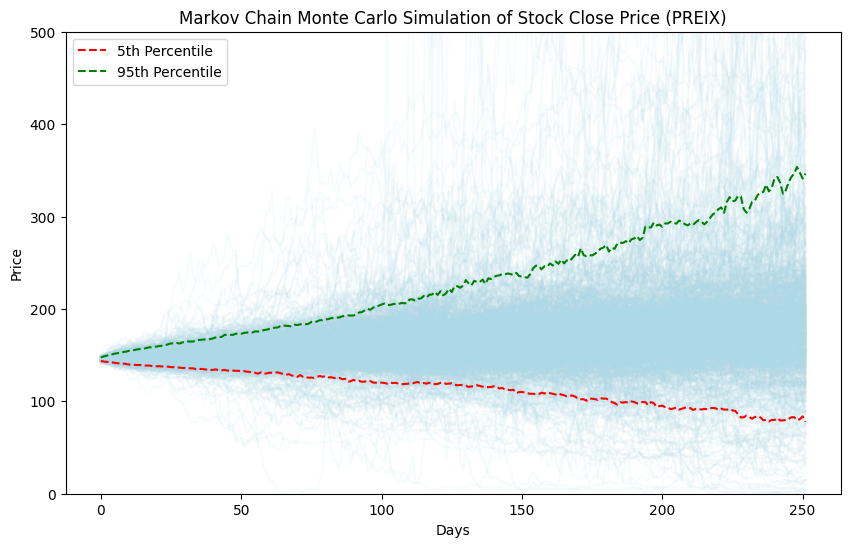

In [ ]:
#mc sim

params = garch_res.params

mu = params['mu']
omega = params['omega']
alpha = params['alpha[1]']
beta = params['beta[1]']
# # Cap alpha + beta to avoid near-IGARCH
if alpha + beta > 0.97:
    scale = 0.97 / (alpha + beta)
    alpha *= scale
    beta *= scale
nu = params['nu']  # degrees of freedom
last_vol = garch_res.conditional_volatility.iloc[-1]
last_resid = garch_res.resid.iloc[-1]

# # Fit the Student's t distribution to the returns data
# params = t.fit(stock_data['Log Return'].dropna())

# # Get the parameters of the distribution
# df_t, mu, sigma = params

# state_params = {}

# for state in states:
#     state_returns = stock_data.loc[
#         stock_data['Markov State'] == state,
#         'Daily Return'
#     ].dropna()

#     state_params[state] = t.fit(state_returns)

# from above
#print("Transition Matrix:\n", transition_matrix)
initial_price = stock_data['Close'].iloc[-1]  # Initial stock price
states = ["Down", "Stagnant", "Up"]

# 4. Monte Carlo Simulation based on Markov Chain
n_simulations = 1000  # Number of simulation paths
n_days = 252  # Simulate for 1 year (252 trading days)

# Initial state probabilities
initial_state = stock_data['Markov State'].iloc[-1]
initial_state_probabilities = [1 if state == initial_state else 0 for state in states]

# Simulating the paths
simulated_paths = []
for sim in range(n_simulations):
    simulated_returns = []
    current_state = np.random.choice(states, p=initial_state_probabilities)
    sigma_t = last_vol
    r_prev = last_resid
    
    for day in range(n_days):
        #Simulate return based on the current state using Student's t-distribution
        # Update conditional variance
        sigma2_t = omega + alpha * (r_prev ** 2) + beta * (sigma_t ** 2)
        sigma_t = np.sqrt(sigma2_t)

        # Draw Student-t innovation
        z_t = np.random.standard_t(df=nu)
        # z_t = np.clip(z_t, -5, 5)  # ±5σ tail cap

        # Optional regime mean shift
        regime_shift = {
            "Up": 0.05,
            "Down": -0.05,
            "Stagnant": 0.0
        }

        # Generate return
        daily_return = mu + sigma_t * z_t

        # Store residual for next iteration
        r_prev = daily_return - mu

        # df_s, mu_s, sigma_s = state_params[current_state]
        # daily_return = t.rvs(df_s, loc=mu_s, scale=sigma_s)
        
        simulated_returns.append(daily_return / 100)
        # Transition to the next state based on the transition matrix
        current_state = np.random.choice(states, p=transition_matrix.loc[current_state, states].values)
        
        # if len(simulated_returns) >= 253:
        #     feat_values = set_stock_data_simulation(simulated_returns[-253:], daily_return)
        #     x_today = scaler.transform(pd.DataFrame([feat_values], columns=features))
        #     probs = transition_models[current_state, states].predict_proba(x_today)[0]
        # else:
        #     today_features_df = pd.DataFrame([transDet.iloc[-1][features].values], columns=features)
        #     x_today = scaler.transform(today_features_df)
        #     probs = P_final.loc[current_state, states].values

        # today_features_df = pd.DataFrame([transDet.iloc[-1][features].values], columns=features)
        # x_today = scaler.transform(today_features_df)
        # probs = transition_models[current_state].predict_proba(x_today)[0]

        # next_state = np.random.choice(states, p=probs)
        # current_state = next_state

    
    # Cumulative price based on returns
    simulated_prices = initial_price * np.exp(np.cumsum(simulated_returns))
    simulated_paths.append(simulated_prices)

# Convert the list of paths to a DataFrame
simulated_paths_df = pd.DataFrame(simulated_paths).T

# 5. Plotting the Monte Carlo simulation
plt.figure(figsize=(10, 6))
plt.plot(simulated_paths_df, color="lightblue", alpha=0.1)

# Add 5% and 95% percentile lines
percentiles_5 = simulated_paths_df.quantile(0.05, axis=1)
percentiles_95 = simulated_paths_df.quantile(0.95, axis=1)

plt.plot(percentiles_5, color="red", linestyle="--", label="5th Percentile")
plt.plot(percentiles_95, color="green", linestyle="--", label="95th Percentile")

# Add labels and title
ticker = "PREIX" #demo ticker remember
plt.title(f"Markov Chain Monte Carlo Simulation of GARCH Data ({ticker})")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.ylim(0, 500)
plt.show()


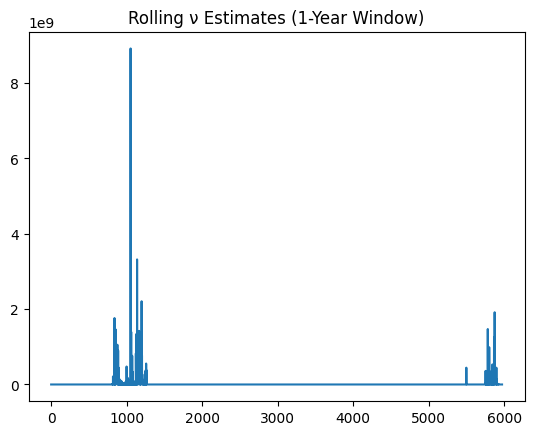

Mean ν: 12124321.625879282
Std ν: 148929299.31260362


In [81]:
window = 252
nus = []

returns = stock_data['Daily Return'].values
returns = stock_data['Daily Return'].values
returns = returns[np.isfinite(returns)]

for i in range(len(returns) - window):
    sample = returns[i:i+window]
    params = t.fit(sample)
    nus.append(params[0])  # df is first parameter

import matplotlib.pyplot as plt

plt.plot(nus)
plt.title("Rolling ν Estimates (1-Year Window)")
plt.show()

print("Mean ν:", np.mean(nus))
print("Std ν:", np.std(nus))

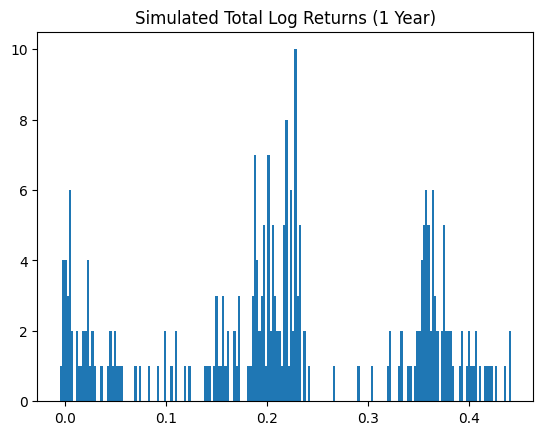

Sim mean: 0.21812953690041026
Sim median: 0.21458820298336514


In [82]:
final_prices = simulated_paths_df.iloc[:, -1]

sim_total_log_return = np.log(final_prices / initial_price)

plt.hist(sim_total_log_return, bins=200)
plt.title("Simulated Total Log Returns (1 Year)")
plt.show()

print("Sim mean:", sim_total_log_return.mean())
print("Sim median:", np.median(sim_total_log_return))



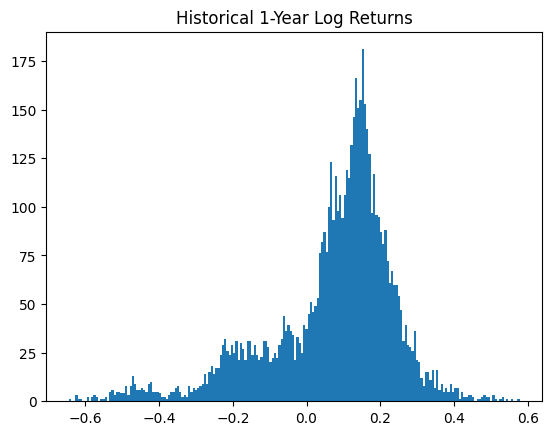

Real mean: 0.07083006543973784
Real median: 0.11231245665102024


In [83]:
log_returns = np.log(1 + stock_data['Daily Return'])

rolling_real = log_returns.rolling(252).sum().dropna()

plt.hist(rolling_real, bins=200)
plt.title("Historical 1-Year Log Returns")
plt.show()

print("Real mean:", rolling_real.mean())
print("Real median:", rolling_real.median())

In [84]:
# ===============================
# Risk Metrics (Robust Version)
# ===============================

confidence_level = 0.95
alpha = 1 - confidence_level

# Final prices from simulation
final_prices = simulated_paths_df.iloc[-1].values

# --- 1. Empirical Confidence Interval (distribution-based) ---
lower_bound = np.percentile(final_prices, alpha * 100)
upper_bound = np.percentile(final_prices, (1 - alpha) * 100)

print(f"95% Empirical Confidence Interval for Final Price: "
      f"({lower_bound:.2f}, {upper_bound:.2f})")

# --- 2. Dollar VaR (how much you could lose) ---
losses = initial_price - final_prices
var_95 = np.percentile(losses, 95)

print(f"95% Value at Risk (Dollar): {var_95:.2f}")

# --- 3. Percentage VaR ---
percent_losses = losses / initial_price
var_95_pct = np.percentile(percent_losses, 95)

print(f"95% Value at Risk (%): {var_95_pct * 100:.2f}%")

# --- 4. Expected Shortfall (CVaR) ---
cvar_95 = losses[losses >= var_95].mean()
print(f"95% Expected Shortfall (CVaR): {cvar_95:.2f}")

# --- 5. Summary Stats ---
print("\nDistribution Diagnostics:")
print(f"Mean Final Price: {np.mean(final_prices):.2f}")
print(f"Median Final Price: {np.median(final_prices):.2f}")
print(f"Minimum Final Price: {np.min(final_prices):.2f}")
print(f"Maximum Final Price: {np.max(final_prices):.2f}")

95% Empirical Confidence Interval for Final Price: (77.86, 346.54)
95% Value at Risk (Dollar): 67.62
95% Value at Risk (%): 46.48%
95% Expected Shortfall (CVaR): 102.91

Distribution Diagnostics:
Mean Final Price: 1542.04
Median Final Price: 179.14
Minimum Final Price: 0.13
Maximum Final Price: 1298438.81
